# Credit Card Fraud Detectection System

## Objective 
Build a machine learning model to detect fraudulent credit card transactions using classification algorithms. The dataset is highly imbalanced, so special techniques are used to improve detection performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 
from sklearn.utils import resample
from sklearn.metrics import precision_recall_curve



In [8]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.info()

df.describe()

df['Class'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64

## Observation From the Above Output
The dataset is highly imbalanced, with far more legitimate transactions than fraudulent ones. This makes accuracy an unreliable metric.

Below we create the features x and the target we want to predict. For x, we say drop the 'Class' column and keep all other columns as the features for training. For y we say keep 'Class' as our target, thats what our model will be predicting.

In [10]:
x = df.drop(['Class'], axis=1)
y = df['Class']

Below we do the train test split 

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
  x, y, 
  test_size=0.2, 
  random_state=42, 
  stratify=y
)

Below we are using SMOTE (Synthetic Minority Oversampling Technique), this is to enure that our inbalance data becomes balanced so the that our modek does not become bias, that is always predicting the majority class and leaving out the minortys

In [12]:
# smote = SMOTE(random_state=42)
# x_train_res, y_train_res = smote.fit_resample(x_train, y_train)
# y_train_res.value_counts()

In [13]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Now we train our first model (baseline), Logistic Regression 

In [14]:
start = time.time()

print('Training Logistic Regression model...')

model = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    class_weight='balanced'  
)

model.fit(x_train, y_train)

end = time.time()

print(f'Training completed in {end - start:.2f} seconds')

Training Logistic Regression model...
Training completed in 3.79 seconds


With the cell below I iterated over some thresholds to find the knee point for my data, at the end, I selected a threshold of 0.8

In [ ]:
# for t in [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]:
#     y_pred = (y_probs > t).astype(int)
#     print(f"\nThreshold: {t}")
#     print(classification_report(y_test, y_pred))

In [ ]:
y_probs = model.predict_proba(x_test)[:, 1]

Commented the cell below because instead of choosing a threshold, I wanted to compute the f1 score to get the best threshold, that is the threshold that gives the highedst f1 score

In [ ]:
# threshold = 0.8

# y_pred = (y_probs > threshold).astype(int)

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# compute F1 for each threshold
f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)

# align shapes (important fix)
f1_scores = f1_scores[:-1]

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1-score:", f1_scores[best_index])

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962



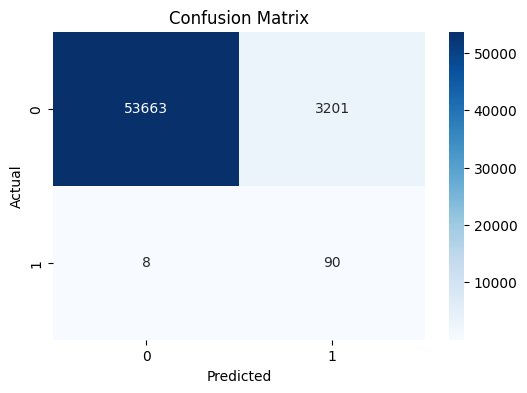

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()